# Lab03 — Outliers & Feature Engineering (Ames Housing)



# 1. Đọc dữ liệu

In [24]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RepeatedKFold, KFold, cross_val_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

TRAIN_PATH = "Data/train_filled.csv"
TEST_PATH  = "Data/test_filled.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

print("Train:", train_raw.shape, "| Test:", test_raw.shape)
display(train_raw.head())

Train: (1460, 81) | Test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [25]:
required_cols = [
    "Id", "GrLivArea", "OverallQual", "GarageCars", "GarageArea",
    "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
    "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath",
    "YearBuilt", "YearRemodAdd", "YrSold", "GarageYrBlt",
    "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch",
    "PoolArea", "Fireplaces"
]
for name, d in [("train", train_raw), ("test", test_raw)]:
    miss = [c for c in required_cols if c not in d.columns]
    print(f"{name}: thiếu cột -> {miss if miss else 'Không có'}")

print("\nSalePrice chỉ có ở train:", "SalePrice" in train_raw.columns, "|", "SalePrice" in test_raw.columns)

train: thiếu cột -> Không có
test: thiếu cột -> Không có

SalePrice chỉ có ở train: True | False


# 2. OUTLIERS — PHÁT HIỆN NGOẠI LỆ

Mục tiêu: tìm các căn nhà **làm lệch mô hình** và quyết định loại hay giữ dựa trên bằng chứng, không loại theo cảm tính.

## 2.1. Quan sát `GrLivArea` – `SalePrice`

De Cock (2011) cảnh báo về các căn có `GrLivArea > 4000 ft²`. Ta vẽ biểu đồ và ghi nhãn `Id` để nhìn rõ từng căn.

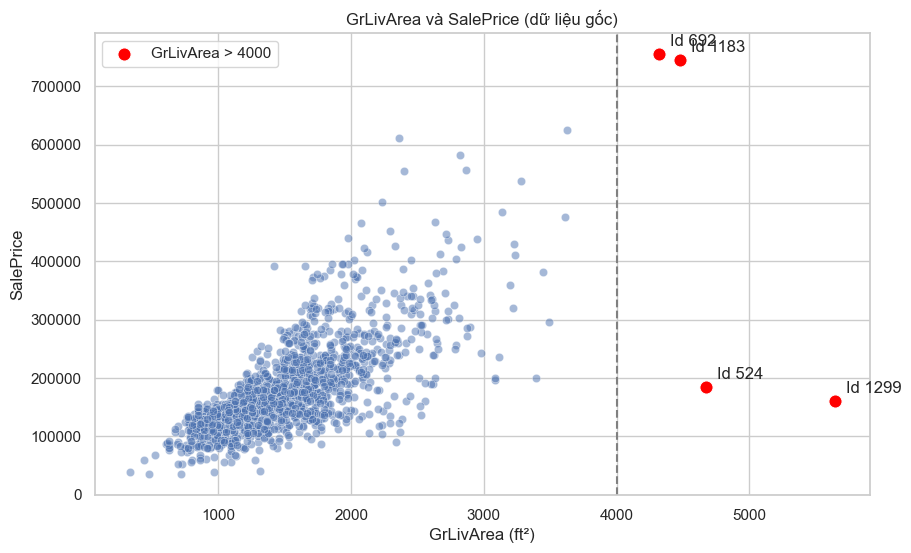

Giá/ft² trung bình toàn tập: 120.6


,Id,GrLivArea,OverallQual,SaleCondition,SalePrice,Giá/ft²
1298,1299,5642,10,Partial,160000,28.4
523,524,4676,10,Partial,184750,39.5
1182,1183,4476,10,Abnorml,745000,166.4
691,692,4316,10,Normal,755000,174.9


In [26]:
big = train_raw[train_raw["GrLivArea"] > 4000]

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=train_raw, x="GrLivArea", y="SalePrice", alpha=0.5, ax=ax)
sns.scatterplot(data=big, x="GrLivArea", y="SalePrice", color="red", s=90, ax=ax, label="GrLivArea > 4000")
for _, r in big.iterrows():
    ax.annotate(f"Id {int(r.Id)}", (r.GrLivArea, r.SalePrice), textcoords="offset points", xytext=(8, 6))
ax.axvline(4000, ls="--", color="gray")
ax.set_title("GrLivArea và SalePrice (dữ liệu gốc)")
ax.set_xlabel("GrLivArea (ft²)"); ax.set_ylabel("SalePrice")
plt.show()

big_tbl = big[["Id", "GrLivArea", "OverallQual", "SaleCondition", "SalePrice"]].copy()
big_tbl["Giá/ft²"] = (big_tbl["SalePrice"] / big_tbl["GrLivArea"]).round(1)
print("Giá/ft² trung bình toàn tập:", round((train_raw.SalePrice / train_raw.GrLivArea).mean(), 1))
display(big_tbl.sort_values("GrLivArea", ascending=False))

### Nhận xét

Có **4** căn vượt 4000 ft², nhưng chúng **không giống nhau**:

- **Id 1299 và Id 524**: diện tích rất lớn nhưng giá chỉ ~160–185 nghìn USD (giá/ft² cực thấp), và cả hai đều có `SaleCondition = Partial` (bán khi chưa hoàn thiện). Đây là giao dịch bất thường, không phản ánh giá thị trường.
- **Id 692 và Id 1183**: diện tích lớn **và** giá ~750 nghìn USD, tức nằm đúng trên xu hướng "nhà càng lớn càng đắt". Đây là các căn cao cấp hợp lệ.

⇒ Quy tắc `GrLivArea > 4000` một mình sẽ loại nhầm 2 căn hợp lệ. Ta kiểm chứng bằng Cook's Distance và Isolation Forest trước khi quyết định.

## 2.2. Cook's Distance (chạy trên dữ liệu **gốc**)

Cook's Distance đo mức độ một quan sát làm thay đổi mô hình hồi quy. Ngưỡng tham khảo thường dùng là `4/n`. Đây là **công cụ chẩn đoán**, không phải lệnh xóa tự động.



In [ ]:
cook_cols = ["GrLivArea", "OverallQual", "TotalBsmtSF", "GarageCars"]
assert train_raw[cook_cols + ["SalePrice"]].isna().sum().sum() == 0  
X_cook = sm.add_constant(train_raw[cook_cols])
y_cook = np.log1p(train_raw["SalePrice"])
ols = sm.OLS(y_cook, X_cook).fit()
cooks_d = ols.get_influence().cooks_distance[0]

cook_thr = 4 / len(train_raw)
train_diag = train_raw[["Id", "GrLivArea", "OverallQual", "SaleCondition", "SalePrice"]].copy()
train_diag["CooksD"] = cooks_d
train_diag["CooksFlag"] = train_diag["CooksD"] > cook_thr

print(f"R² mô hình OLS chẩn đoán: {ols.rsquared:.3f}")
print(f"Ngưỡng 4/n = {cook_thr:.5f} | số quan sát vượt ngưỡng: {train_diag.CooksFlag.sum()}")
display(train_diag.sort_values("CooksD", ascending=False).head(10))

R² mô hình OLS chẩn đoán: 0.794
Ngưỡng 4/n = 0.00274 | số quan sát vượt ngưỡng: 80


,Id,GrLivArea,OverallQual,SaleCondition,SalePrice,CooksD,CooksFlag
1298,1299,5642,10,Partial,160000,4.997501,True
523,524,4676,10,Partial,184750,0.461242,True
495,496,720,4,Abnorml,34900,0.022685,True
676,677,1774,4,Normal,87000,0.022100,True
1349,1350,2358,8,Normal,122000,0.021804,True
916,917,480,2,Abnorml,35311,0.019342,True
968,969,968,3,Abnorml,37900,0.016630,True
1062,1063,2337,5,Normal,90000,0.015299,True
30,31,1317,4,Normal,40000,0.015130,True
728,729,1776,5,Abnorml,110000,0.014392,True


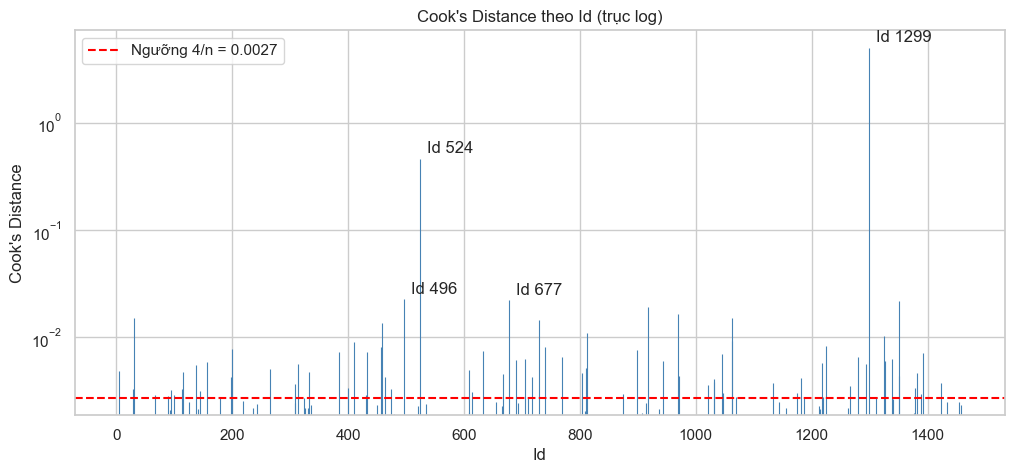

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.vlines(train_diag["Id"], 0, train_diag["CooksD"], lw=0.8, color="steelblue")
ax.axhline(cook_thr, color="red", ls="--", label=f"Ngưỡng 4/n = {cook_thr:.4f}")
ax.set_yscale("log")
for _, r in train_diag.nlargest(4, "CooksD").iterrows():
    ax.annotate(f"Id {int(r.Id)}", (r.Id, r.CooksD), textcoords="offset points", xytext=(5, 4))
ax.set_title("Cook's Distance theo Id (trục log)")
ax.set_xlabel("Id"); ax.set_ylabel("Cook's Distance"); ax.legend()
plt.show()

### Nhận xét Cook's Distance

Hai căn nổi bật vượt xa mọi quan sát còn lại là **Id 1299** (≈5.0) và **Id 524** (≈0.46); căn lớn thứ ba chỉ khoảng 0.02. Trong khi đó **Id 692 và Id 1183 không nằm trong nhóm ảnh hưởng mạnh**, đúng như nhận định "đây là nhà cao cấp hợp lệ".

Số quan sát vượt ngưỡng `4/n` khá nhiều (~80, vì ngưỡng này khá nhạy với n lớn), nên **không** loại tất cả. Ta chỉ dùng nó để xếp hạng mức độ ảnh hưởng.

## 2.3. Isolation Forest (chạy trên dữ liệu **gốc**)

Isolation Forest xét đồng thời nhiều biến để tìm các căn "khác biệt so với đa số". `contamination = 0.02` nghĩa là ta giả định khoảng 2% dữ liệu bất thường (đây là tham số chọn tay, không phải sự thật).

In [29]:
iso_cols = ["OverallQual", "GrLivArea", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
            "GarageCars", "GarageArea", "SalePrice"]
assert train_raw[iso_cols].isna().sum().sum() == 0

X_iso = StandardScaler().fit_transform(train_raw[iso_cols])
iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=42).fit(X_iso)

train_diag["IsoFlag"]  = iso.predict(X_iso) == -1
train_diag["IsoScore"] = iso.score_samples(X_iso)      # càng thấp càng bất thường

print("Số quan sát bị Isolation Forest đánh dấu:", train_diag.IsoFlag.sum())
display(train_diag[train_diag.IsoFlag].sort_values("IsoScore").head(12))

Số quan sát bị Isolation Forest đánh dấu: 30


,Id,GrLivArea,OverallQual,SaleCondition,SalePrice,CooksD,CooksFlag,IsoFlag,IsoScore
1298,1299,5642,10,Partial,160000,4.997501,True,True,-0.731321
1182,1183,4476,10,Abnorml,745000,0.000723,False,True,-0.730161
691,692,4316,10,Normal,755000,0.001583,False,True,-0.730127
523,524,4676,10,Partial,184750,0.461242,True,True,-0.712029
1169,1170,3627,10,Normal,625000,0.001267,False,True,-0.694419
496,497,3228,8,Normal,430000,0.000117,False,True,-0.674582
533,534,334,1,Normal,39300,0.002394,False,True,-0.670736
635,636,3395,6,Abnorml,200000,0.000086,False,True,-0.663387
1373,1374,2633,10,Normal,466500,0.000282,False,True,-0.660358
440,441,2402,10,Normal,555000,0.000780,False,True,-0.659961


### Nhận xét Isolation Forest

Isolation Forest đánh dấu cả 4 căn > 4000 ft² cùng nhiều căn giá rất cao hoặc rất thấp. Điều này hợp lý vì nó chỉ đo độ "hiếm" của một căn, **không phân biệt hiếm do dữ liệu lỗi hay hiếm do là nhà cao cấp**. Vì vậy kết quả này cần đối chiếu với Cook's Distance và kiến thức nghiệp vụ.

## 2.4. Tổng hợp bằng chứng và quyết định

In [30]:
decision = train_diag[train_diag["GrLivArea"] > 4000].copy()
decision["Giá/ft²"] = (decision["SalePrice"] / decision["GrLivArea"]).round(1)
decision["CooksD"]  = decision["CooksD"].round(4)
decision["Quyết định"] = np.where(decision["SalePrice"] < 300_000, "LOẠI (bất thường)", "GIỮ (nhà cao cấp hợp lệ)")
display(decision[["Id", "GrLivArea", "SaleCondition", "SalePrice", "Giá/ft²", "CooksD", "IsoFlag", "Quyết định"]]
        .sort_values("GrLivArea", ascending=False))

,Id,GrLivArea,SaleCondition,SalePrice,Giá/ft²,CooksD,IsoFlag,Quyết định
1298,1299,5642,Partial,160000,28.4,4.9975,True,LOẠI (bất thường)
523,524,4676,Partial,184750,39.5,0.4612,True,LOẠI (bất thường)
1182,1183,4476,Abnorml,745000,166.4,0.0007,True,GIỮ (nhà cao cấp hợp lệ)
691,692,4316,Normal,755000,174.9,0.0016,True,GIỮ (nhà cao cấp hợp lệ)


**Quy tắc xử lý chính thức:**

> Loại các căn có `GrLivArea > 4000` **và** `SalePrice < 300000` khỏi tập train.

Lý do: khớp với mô tả của De Cock (diện tích rất lớn nhưng giá thấp bất thường), được Cook's Distance xác nhận (Id 1299, 524), và **giữ lại** hai căn hợp lệ Id 692, 1183. Quy tắc chỉ dựa vào đặc điểm của từng căn nên có thể giải thích được, không dựa vào việc "mô hình chạy đẹp hơn".

In [31]:
OUTLIER_MASK = (train_raw["GrLivArea"] > 4000) & (train_raw["SalePrice"] < 300_000)

removed = train_raw[OUTLIER_MASK].copy()
train_clean = train_raw[~OUTLIER_MASK].copy().reset_index(drop=True)

print("Train trước :", train_raw.shape[0])
print("Train sau   :", train_clean.shape[0])
print("Id bị loại  :", removed["Id"].tolist())
print("Test        :", test_raw.shape[0], "(giữ nguyên, không xóa dòng nào)")
removed.to_csv("removed_outliers.csv", index=False)

Train trước : 1460
Train sau   : 1458
Id bị loại  : [524, 1299]
Test        : 1459 (giữ nguyên, không xóa dòng nào)


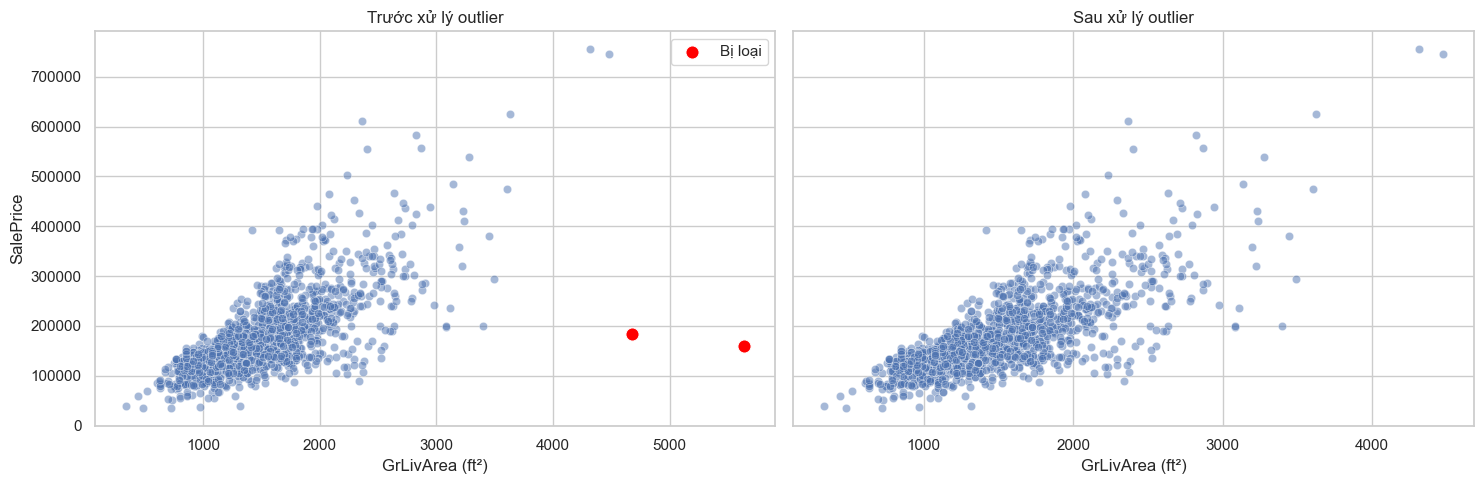

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.scatterplot(data=train_raw, x="GrLivArea", y="SalePrice", alpha=0.5, ax=axes[0])
sns.scatterplot(data=removed,   x="GrLivArea", y="SalePrice", color="red", s=90, ax=axes[0], label="Bị loại")
axes[0].set_title("Trước xử lý outlier")
sns.scatterplot(data=train_clean, x="GrLivArea", y="SalePrice", alpha=0.5, ax=axes[1])
axes[1].set_title("Sau xử lý outlier")
for a in axes: a.set_xlabel("GrLivArea (ft²)")
plt.tight_layout(); plt.show()

## 2.5. Danh sách theo dõi (đánh dấu nhưng không loại)

Các căn bị **cả hai** phương pháp đánh dấu nhưng không thuộc quy tắc loại bỏ được giữ lại và ghi vào danh sách theo dõi. Khi chạy mô hình, nhóm có thể xem sai số của các căn này để cân nhắc thêm.

In [33]:
watch = train_diag[(train_diag.CooksFlag) & (train_diag.IsoFlag) & (~train_diag.Id.isin(removed.Id))]
print("Số căn nằm trong danh sách theo dõi:", len(watch))
display(watch.sort_values("CooksD", ascending=False)[["Id", "GrLivArea", "OverallQual", "SaleCondition", "SalePrice", "CooksD"]])

Số căn nằm trong danh sách theo dõi: 8


,Id,GrLivArea,OverallQual,SaleCondition,SalePrice,CooksD
1349,1350,2358,8,Normal,122000,0.021804
898,899,2364,9,Partial,611657,0.007675
769,770,3279,8,Normal,538000,0.006588
705,706,1092,4,Normal,55000,0.006353
803,804,2822,9,Partial,582933,0.004674
1046,1047,2868,9,Partial,556581,0.003017
1173,1174,3086,5,Normal,200500,0.003003
178,179,2234,9,Partial,501837,0.002762


## 2.6. Kiểm chứng: quyết định loại 2 căn có thực sự tốt hơn không?

So sánh 3 phương án bằng cross-validation (Ridge, đích `log1p(SalePrice)`, RMSLE), **luôn đánh giá trên cùng một tập** gồm tất cả căn trừ Id 524 và 1299. Tập đánh giá vẫn gồm hai căn đắt hợp lệ (692, 1183), nên phương án nào loại nhầm chúng sẽ bị phạt.

- **A. Giữ cả 4**: không loại gì.
- **B. Loại cả 4** (quy tắc `GrLivArea > 4000` đơn thuần).
- **C. Loại 2** (quy tắc đề xuất).

*(Đoạn mã kiểm chứng dùng hàm `create_features` nên được đặt ở mục 3.4, sau khi hàm được định nghĩa.)*

# 3. FEATURE ENGINEERING

Các đặc trưng mới được thiết kế để mô phỏng cách thị trường định giá: **quy mô**, **tiện nghi**, **tuổi/khấu hao** và **chất lượng × diện tích**.

## 3.1. Các vấn đề dữ liệu phải xử lý trước khi tạo feature

Kiểm tra cho thấy dữ liệu có vài giá trị vô lý mà nếu không xử lý sẽ sinh feature sai:

In [34]:
def age_problems(d, name):
    print(f"[{name}]")
    print("  HouseAge  < 0 :", (d.YrSold - d.YearBuilt < 0).sum())
    print("  RemodAge  < 0 :", (d.YrSold - d.YearRemodAdd < 0).sum())
    print("  GarageAge < 0 :", (d.YrSold - d.GarageYrBlt < 0).sum(), "| GarageYrBlt lớn nhất:", d.GarageYrBlt.max())

age_problems(train_raw, "train")
age_problems(test_raw, "test")
display(test_raw[test_raw.GarageYrBlt > test_raw.YrSold][["Id", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold"]])

[train]
  HouseAge  < 0 : 0
  RemodAge  < 0 : 1
  GarageAge < 0 : 0 | GarageYrBlt lớn nhất: 2010.0
[test]
  HouseAge  < 0 : 1
  RemodAge  < 0 : 2
  GarageAge < 0 : 2 | GarageYrBlt lớn nhất: 2207.0


,Id,YearBuilt,YearRemodAdd,GarageYrBlt,YrSold
1089,2550,2008,2009,2008.0,2007
1132,2593,2006,2007,2207.0,2007


Phát hiện:
- Có căn được **cải tạo / xây gara sau năm bán** (bán khi còn đang xây) ⇒ tuổi âm.
- Test có `GarageYrBlt = 2207` (rõ ràng là lỗi gõ, đúng ra là 2007).

Cách xử lý: **chặn tuổi tối thiểu bằng 0** (`clip(lower=0)`). Với mọi trường hợp trên kết quả đều là 0 (căn mới), đúng ý nghĩa thực tế.

Với căn **không có gara** (`GarageYrBlt` rỗng), `GarageAge = 0` sẽ trùng với "gara mới xây". Vì vậy cần đi kèm cờ `HasGarage` để mô hình phân biệt.

In [35]:
def create_features(data):
    """Tạo đặc trưng mới. Dùng chung cho train và test (không dùng thông tin từ SalePrice)."""
    d = data.copy()
    z = lambda c: d[c].fillna(0)          # biến diện tích/số lượng: NaN nghĩa là không có -> 0

    # --- Quy mô ---
    d["TotalSF"]       = z("TotalBsmtSF") + z("1stFlrSF") + z("2ndFlrSF")
    d["TotalPorchSF"]  = z("OpenPorchSF") + z("EnclosedPorch") + z("3SsnPorch") + z("ScreenPorch")

    # --- Tiện nghi ---
    d["TotalBath"]     = z("FullBath") + 0.5 * z("HalfBath") + z("BsmtFullBath") + 0.5 * z("BsmtHalfBath")
    d["HasPool"]       = (z("PoolArea") > 0).astype(int)
    d["HasGarage"]     = (z("GarageArea") > 0).astype(int)
    d["HasFireplace"]  = (z("Fireplaces") > 0).astype(int)

    # --- Tuổi / khấu hao (chặn dưới = 0) ---
    d["HouseAge"]      = (d["YrSold"] - d["YearBuilt"]).clip(lower=0)
    d["RemodAge"]      = (d["YrSold"] - d["YearRemodAdd"]).clip(lower=0)
    garage_age         = (d["YrSold"] - d["GarageYrBlt"]).clip(lower=0)
    d["GarageAge"]     = np.where(d["HasGarage"] == 1, garage_age.fillna(0), 0)
    d["IsRemodeled"]   = (d["YearRemodAdd"] != d["YearBuilt"]).astype(int)

    # --- Tương tác chất lượng x quy mô ---
    d["QualArea"]      = d["OverallQual"] * d["GrLivArea"]
    d["QualTotalSF"]   = d["OverallQual"] * d["TotalSF"]
    return d

new_features = ["TotalSF", "TotalBath", "HouseAge", "RemodAge", "GarageAge", "IsRemodeled",
                "TotalPorchSF", "HasPool", "HasGarage", "HasFireplace", "QualArea", "QualTotalSF"]

train_fe = create_features(train_clean)
test_fe  = create_features(test_raw)
display(train_fe[new_features].head())

,TotalSF,TotalBath,HouseAge,RemodAge,GarageAge,IsRemodeled,TotalPorchSF,HasPool,HasGarage,HasFireplace,QualArea,QualTotalSF
0,2566,3.5,5,5,5.0,0,61,0,1,0,11970,17962
1,2524,2.5,31,31,31.0,0,0,0,1,1,7572,15144
2,2706,3.5,7,6,7.0,1,42,0,1,1,12502,18942
3,2473,2.0,91,36,8.0,1,307,0,1,1,12019,17311
4,3343,3.5,8,8,8.0,0,84,0,1,1,17584,26744


## 3.2. Giải thích các đặc trưng

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` | Tổng diện tích sử dụng |
| `TotalBath` | Full + 0.5·Half + BsmtFull + 0.5·BsmtHalf | Số phòng tắm quy đổi (nửa phòng tính 0.5) |
| `TotalPorchSF` | Open + Enclosed + 3Ssn + Screen | Tổng diện tích hiên/sân |
| `HouseAge` | `YrSold − YearBuilt` (≥ 0) | Tuổi nhà lúc bán |
| `RemodAge` | `YrSold − YearRemodAdd` (≥ 0) | Số năm từ lần cải tạo gần nhất |
| `GarageAge` | `YrSold − GarageYrBlt` (≥ 0; 0 nếu không gara) | Tuổi gara |
| `IsRemodeled` | `YearRemodAdd ≠ YearBuilt` | Nhà đã từng cải tạo |
| `HasPool / HasGarage / HasFireplace` | Diện tích hoặc số lượng > 0 | Có/không có tiện nghi |
| `QualArea` | `OverallQual × GrLivArea` | Diện tích sống điều chỉnh theo chất lượng |
| `QualTotalSF` | `OverallQual × TotalSF` | Tổng diện tích điều chỉnh theo chất lượng |

## 3.3. Kiểm tra tính hợp lệ

In [36]:
# 1) Không NaN, không giá trị âm
for name, d in [("train", train_fe), ("test", test_fe)]:
    assert d[new_features].isna().sum().sum() == 0, f"{name}: còn NaN trong feature mới"
    assert (d[new_features] >= 0).all().all(), f"{name}: có giá trị âm"
print("OK: feature mới không NaN và không âm ở cả train lẫn test.")

# 2) Train và test có cùng bộ feature
assert set(new_features).issubset(train_fe.columns) and set(new_features).issubset(test_fe.columns)
print("OK: train và test có cùng bộ feature mới.\n")

display(train_fe[new_features].describe().T[["count", "mean", "min", "max"]])

OK: feature mới không NaN và không âm ở cả train lẫn test.
OK: train và test có cùng bộ feature mới.



,count,mean,min,max
TotalSF,1458.0,2557.150206,334.0,6872.0
TotalBath,1458.0,2.207476,1.0,6.0
HouseAge,1458.0,36.598080,0.0,136.0
RemodAge,1458.0,22.982167,0.0,60.0
GarageAge,1458.0,27.718107,0.0,107.0
IsRemodeled,1458.0,0.476680,0.0,1.0
TotalPorchSF,1458.0,86.725652,0.0,1027.0
HasPool,1458.0,0.004115,0.0,1.0
HasGarage,1458.0,0.944444,0.0,1.0
HasFireplace,1458.0,0.526749,0.0,1.0


## 3.4. Quay lại mục 2.6 — kiểm chứng phương án loại outlier

In [37]:
base_feats = ["OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars", "YearBuilt", "FullBath"]
all_fe = create_features(train_raw)

def cv_rmsle(drop_from_train=(), extra_ids=(), n_repeats=5, seed=42):
    """Đánh giá trên mọi căn trừ Id 524, 1299. Có thể bỏ một số căn khỏi tập TRAIN (nhưng vẫn đánh giá chúng)
    hoặc thêm 524/1299 vào tập train."""
    E = all_fe[~all_fe.Id.isin([524, 1299])].reset_index(drop=True)
    extra = all_fe[all_fe.Id.isin(extra_ids)]
    rkf = RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=seed)
    errs = []
    for tr_idx, va_idx in rkf.split(E):
        tr = E.iloc[tr_idx]
        tr = tr[~tr.Id.isin(drop_from_train)]
        tr = pd.concat([tr, extra])
        va = E.iloc[va_idx]
        m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(tr[base_feats], np.log1p(tr.SalePrice))
        errs.append(np.sqrt(np.mean((m.predict(va[base_feats]) - np.log1p(va.SalePrice)) ** 2)))
    return np.mean(errs), np.std(errs)

res = {
    "A. Giữ cả 4":                      cv_rmsle(extra_ids=[524, 1299]),
    "B. Loại cả 4 (GrLivArea > 4000)":  cv_rmsle(drop_from_train=[692, 1183]),
    "C. Loại 2 (đề xuất)":              cv_rmsle(),
}
cmp = pd.DataFrame(res, index=["RMSLE trung bình", "Độ lệch chuẩn"]).T.round(5)
display(cmp)

,RMSLE trung bình,Độ lệch chuẩn
A. Giữ cả 4,0.16076,0.00801
B. Loại cả 4 (GrLivArea > 4000),0.15624,0.00827
C. Loại 2 (đề xuất),0.15623,0.00827


### Kết luận mục 2.6

- **Giữ cả 4** cho sai số cao nhất (≈ 0.161) ⇒ hai căn Id 524/1299 thật sự làm lệch mô hình, cần loại.
- **B và C gần như bằng nhau** (≈ 0.156): vì chỉ có 2 căn (692, 1183) khác biệt giữa hai phương án nên tác động lên sai số trung bình rất nhỏ. Kết quả này **không** cho thấy loại 4 tệ hơn loại 2.
- Vì vậy lý do chọn phương án C không dựa vào con số RMSLE mà dựa vào **bằng chứng từng căn**: 692 và 1183 có giá/ft² bình thường, Cook's Distance rất thấp, là nhà cao cấp hợp lệ. Giữ chúng giúp mô hình vẫn "nhìn thấy" phân khúc nhà đắt.

# 4. ĐÁNH GIÁ FEATURE MỚI

## 4.1. Tương quan với `SalePrice` và `log1p(SalePrice)`

Biến mục tiêu đã được log hóa ở phần của Thái, nên ta so tương quan với cả hai dạng. Tương quan chỉ đo quan hệ tuyến tính, không chứng minh nhân quả.

In [38]:
tmp = train_fe.copy()
tmp["logSalePrice"] = np.log1p(tmp["SalePrice"])
compare_cols = new_features + ["GrLivArea", "OverallQual", "GarageCars", "TotalBsmtSF"]

corr_tbl = pd.DataFrame({
    "corr_SalePrice":    tmp[compare_cols].corrwith(tmp["SalePrice"]),
    "corr_logSalePrice": tmp[compare_cols].corrwith(tmp["logSalePrice"]),
}).sort_values("corr_logSalePrice", ascending=False).round(3)
corr_tbl["Loại"] = np.where(corr_tbl.index.isin(new_features), "Feature mới", "Biến gốc (tham chiếu)")
display(corr_tbl)

,corr_SalePrice,corr_logSalePrice,Loại
QualTotalSF,0.919,0.883,Feature mới
QualArea,0.874,0.838,Feature mới
TotalSF,0.833,0.825,Feature mới
OverallQual,0.796,0.821,Biến gốc (tham chiếu)
GrLivArea,0.735,0.725,Biến gốc (tham chiếu)
GarageCars,0.641,0.681,Biến gốc (tham chiếu)
TotalBath,0.636,0.677,Feature mới
TotalBsmtSF,0.651,0.648,Biến gốc (tham chiếu)
HasFireplace,0.472,0.510,Feature mới
HasGarage,0.237,0.323,Feature mới


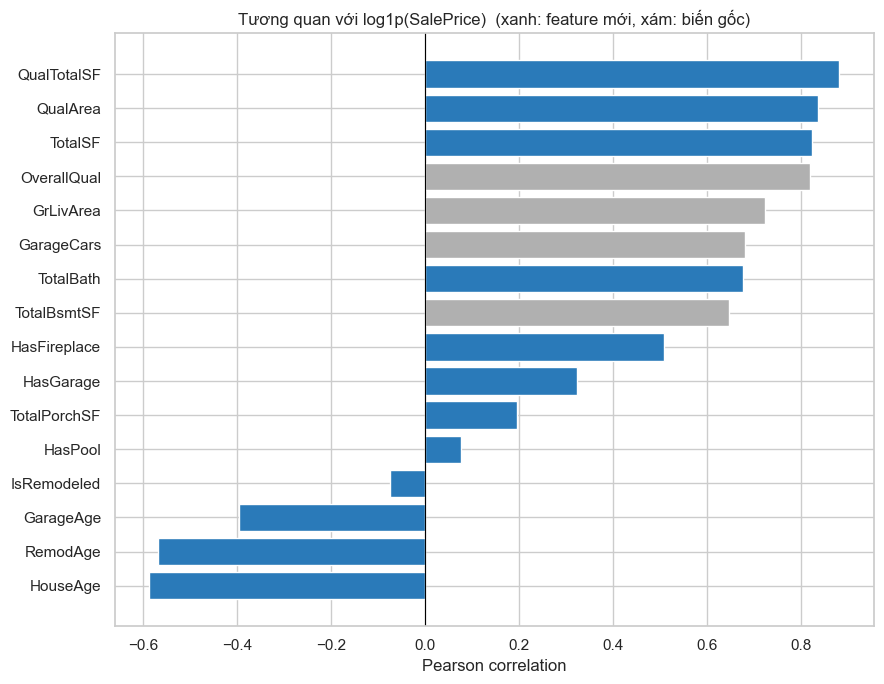

In [39]:
plot_df = corr_tbl.sort_values("corr_logSalePrice")
colors = np.where(plot_df["Loại"] == "Feature mới", "#2a7ab9", "#b0b0b0")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_df.index, plot_df["corr_logSalePrice"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Tương quan với log1p(SalePrice)  (xanh: feature mới, xám: biến gốc)")
ax.set_xlabel("Pearson correlation")
plt.tight_layout(); plt.show()

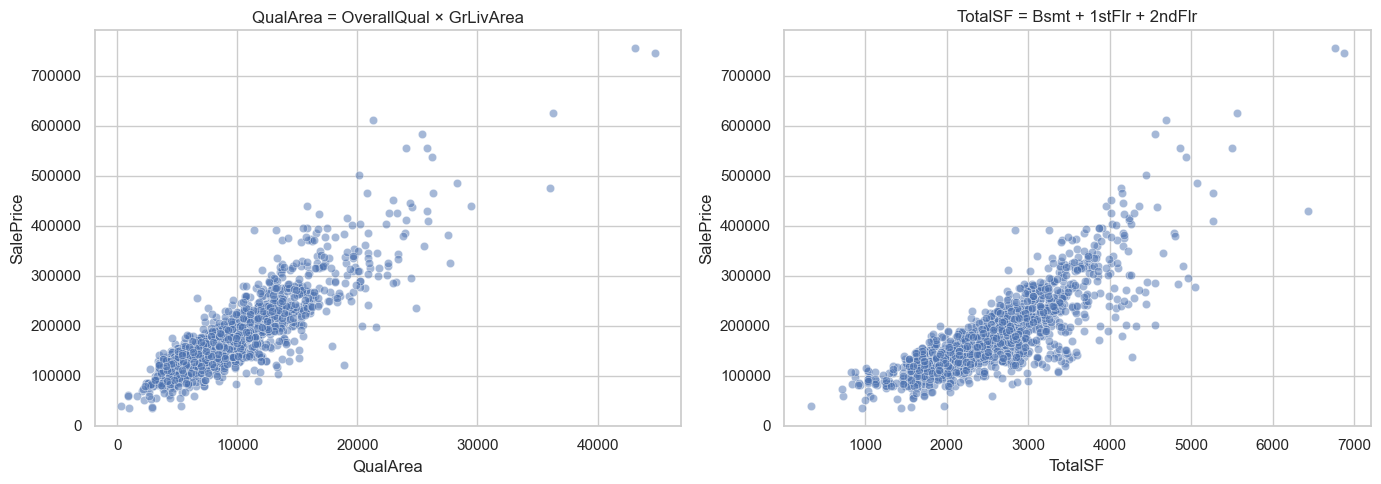

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=train_fe, x="QualArea", y="SalePrice", alpha=0.5, ax=axes[0])
axes[0].set_title("QualArea = OverallQual × GrLivArea")
sns.scatterplot(data=train_fe, x="TotalSF", y="SalePrice", alpha=0.5, ax=axes[1])
axes[1].set_title("TotalSF = Bsmt + 1stFlr + 2ndFlr")
plt.tight_layout(); plt.show()

## 4.2. Feature mới có thật sự giúp mô hình?

Tương quan cao chưa chắc đã cải thiện dự đoán. Ta so sánh Ridge với **bộ biến gốc** và **bộ biến gốc + feature mới** bằng cross-validation 5-fold × 5 lần (RMSLE, càng thấp càng tốt).

In [41]:
y = np.log1p(train_fe["SalePrice"])
base = ["OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars", "YearBuilt", "FullBath"]
sets = {
    "Chỉ biến gốc":             base,
    "Gốc + feature mới":        base + new_features,
}
rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
rows = {}
for name, cols in sets.items():
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    s = -cross_val_score(pipe, train_fe[cols], y, cv=rkf, scoring="neg_root_mean_squared_error")
    rows[name] = (s.mean(), s.std())
fe_cmp = pd.DataFrame(rows, index=["RMSLE trung bình", "Độ lệch chuẩn"]).T.round(5)
display(fe_cmp)
gain = (1 - fe_cmp.iloc[1, 0] / fe_cmp.iloc[0, 0]) * 100
print(f"Mức giảm RMSLE nhờ feature mới: {gain:.1f}%")

,RMSLE trung bình,Độ lệch chuẩn
Chỉ biến gốc,0.15623,0.00827
Gốc + feature mới,0.14429,0.00754


Mức giảm RMSLE nhờ feature mới: 7.6%


**Lưu ý cho Mai (đa cộng tuyến):** các feature tổng hợp được tạo từ biến gốc nên sẽ **tương quan rất cao với chính các thành phần của nó** (ví dụ `TotalSF` với `TotalBsmtSF`, `1stFlrSF`; `QualArea` với `GrLivArea`). Khi chạy VIF, nên cân nhắc giữ feature tổng hợp và bỏ bớt thành phần (hoặc ngược lại) thay vì giữ cả hai.

In [42]:
parts = ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GrLivArea"]
display(train_fe[["TotalSF", "QualArea"] + parts].corr().loc[["TotalSF", "QualArea"], parts + ["TotalSF", "QualArea"]].round(2))

,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,TotalSF,QualArea
TotalSF,0.81,0.78,0.34,0.87,1.00,0.88
QualArea,0.51,0.56,0.59,0.92,0.88,1.00


# 5. MÃ HÓA ĐẶC TRƯNG (theo mục 8.4 của báo cáo)

Hai kỹ thuật được áp dụng và **chỉ học từ train** (rồi áp dụng nguyên cho test) để không rò rỉ thông tin:

1. **Ordinal Encoding** cho các biến chất lượng (`Po < Fa < TA < Gd < Ex` → 1…5).
2. **Rare Label Binning** (nhãn xuất hiện < 5% ở train → `"Other"`) cho biến danh nghĩa nhiều nhãn.

Các cột mới được tạo thêm với hậu tố `_Ord` / `_Bin`, **không ghi đè cột gốc** để không xung đột với pipeline của các bạn khác. One-Hot Encoding để lại cho bước mô hình hóa.

In [43]:
QUAL_MAP = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

# NaN = "không có hạng mục đó" -> 0
ORD_STRUCTURAL = ["BsmtQual", "BsmtCond", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]
# Không có ý nghĩa "không có" -> NaN chỉ là thiếu ngẫu nhiên, điền mode của train
ORD_RANDOM     = ["ExterQual", "ExterCond", "HeatingQC", "KitchenQual"]
RARE_COLS      = ["Exterior1st", "Exterior2nd"]
RARE_THRESHOLD = 0.05

# ---- fit CHỈ trên train ----
ord_modes = {c: train_clean[c].mode()[0] for c in ORD_RANDOM}
rare_keep = {}
for c in RARE_COLS:
    freq = train_clean[c].value_counts(normalize=True)
    rare_keep[c] = set(freq[freq >= RARE_THRESHOLD].index)

def encode(data):
    d = data.copy()
    for c in ORD_STRUCTURAL:
        d[c + "_Ord"] = d[c].fillna("None").map(QUAL_MAP)
    for c in ORD_RANDOM:
        d[c + "_Ord"] = d[c].fillna(ord_modes[c]).map(QUAL_MAP)
    for c in RARE_COLS:
        d[c + "_Bin"] = np.where(d[c].isin(rare_keep[c]), d[c], "Other")
    return d

train_fe = encode(train_fe)
test_fe  = encode(test_fe)

ord_new = [c + "_Ord" for c in ORD_STRUCTURAL + ORD_RANDOM]
bin_new = [c + "_Bin" for c in RARE_COLS]
assert train_fe[ord_new].isna().sum().sum() == 0 and test_fe[ord_new].isna().sum().sum() == 0
print("Nhãn được giữ lại ở train:")
for c in RARE_COLS: print(f"  {c}: {sorted(rare_keep[c])}")
display(train_fe[bin_new[0]].value_counts().to_frame())

Nhãn được giữ lại ở train:
  Exterior1st: ['HdBoard', 'MetalSd', 'Plywood', 'VinylSd', 'Wd Sdng']
  Exterior2nd: ['HdBoard', 'MetalSd', 'Plywood', 'VinylSd', 'Wd Sdng']


,count
Exterior1st_Bin,
VinylSd,515
HdBoard,222
MetalSd,220
Wd Sdng,206
Other,187
Plywood,108


**Vì sao không áp dụng Rare Binning cho `Neighborhood`?** Báo cáo đề cập `Neighborhood`, nhưng với ngưỡng 5% hầu hết khu phố sẽ bị gộp thành "Other". Nhiều khu hiếm như `NoRidge`, `StoneBr`, `Veenker`, `Timber` lại thuộc nhóm khu **đắt nhất** (bảng dưới), nên gộp chúng sẽ làm mất tín hiệu vị trí quan trọng nhất. Với `Neighborhood` nên dùng Target Encoding hoặc One-Hot đầy đủ ở bước mô hình hóa.

In [44]:
nb = (train_fe.groupby("Neighborhood")["SalePrice"]
      .agg(Số_căn="count", Giá_trung_vị="median")
      .assign(Tỷ_lệ=lambda x: (x["Số_căn"] / len(train_fe) * 100).round(1))
      .sort_values("Giá_trung_vị", ascending=False))
print("Số khu phố có tỷ lệ < 5%:", (nb["Tỷ_lệ"] < 5).sum(), "/", len(nb))
display(nb.head(8))

Số khu phố có tỷ lệ < 5%: 16 / 25


,Số_căn,Giá_trung_vị,Tỷ_lệ
Neighborhood,,,
NridgHt,77,315000.0,5.3
NoRidge,41,301500.0,2.8
StoneBr,25,278000.0,1.7
Timber,38,228475.0,2.6
Somerst,86,225500.0,5.9
Veenker,11,218000.0,0.8
Crawfor,51,200624.0,3.5
ClearCr,28,200250.0,1.9


# 6. XUẤT DỮ LIỆU CHO BƯỚC TIẾP THEO

In [45]:
train_fe.to_csv("train_engineered.csv", index=False)
test_fe.to_csv("test_engineered.csv", index=False)

print("========== TỔNG KẾT ==========")
print(f"Train gốc            : {train_raw.shape}")
print(f"Train sau xử lý      : {train_fe.shape}  (loại Id {removed.Id.tolist()})")
print(f"Test sau FE          : {test_fe.shape}  (không xóa dòng)")
print(f"Feature số mới       : {len(new_features)}")
print(f"Cột mã hóa mới       : {len(ord_new) + len(bin_new)}")
print("Cột lệch giữa train/test (trừ SalePrice):", set(train_fe.columns) ^ set(test_fe.columns))

========== TỔNG KẾT ==========
Train gốc            : (1460, 81)
Train sau xử lý      : (1458, 105)  (loại Id [524, 1299])
Test sau FE          : (1459, 104)  (không xóa dòng)
Feature số mới       : 12
Cột mã hóa mới       : 12
Cột lệch giữa train/test (trừ SalePrice): {'SalePrice'}


# 7. KẾT LUẬN

## Outliers
- Phát hiện bằng 3 góc nhìn: biểu đồ `GrLivArea`–`SalePrice`, **Cook's Distance** và **Isolation Forest**, đều chạy trên dữ liệu gốc.
- Có 4 căn > 4000 ft², nhưng chỉ **Id 1299 và Id 524** là bất thường thật (giá rất thấp so với diện tích, bán ở trạng thái `Partial`, Cook's Distance vượt xa phần còn lại). **Id 692 và 1183** là nhà cao cấp hợp lệ nên được giữ.
- Quy tắc loại: `GrLivArea > 4000` **và** `SalePrice < 300000` ⇒ loại **2** quan sát khỏi train; test giữ nguyên.
- Cook's Distance và Isolation Forest dùng để chẩn đoán; các căn bị cả hai đánh dấu nhưng không bị loại được đưa vào danh sách theo dõi.

## Feature Engineering
- Tạo 12 đặc trưng mới (quy mô, tiện nghi, tuổi/khấu hao, tương tác chất lượng–diện tích), xử lý các giá trị vô lý (tuổi âm, `GarageYrBlt = 2207`).
- Hàm `create_features` dùng chung cho train và test.
- Đã kiểm chứng bằng tương quan và cross-validation (mục 4.2): thêm feature mới giúp RMSLE giảm từ ≈ 0.156 xuống ≈ 0.144 (khoảng 7.6%) với mô hình Ridge đơn giản.
- Mã hóa Ordinal cho biến chất lượng và Rare Label Binning cho `Exterior1st/2nd` (fit trên train).

